In [4]:
 # problem statment : either note is genuine or fake note using predictive
 # modeling and with the help of dicision tree

# New Section

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns

In [6]:
df= pd.read_csv('banknotes.csv') # load the data
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [7]:
# lets create input and output data
x = df.drop(columns='Class')
x[:3]

,Variance,Skewness,Curtosis,Entropy
0,3.6216,8.6661,-2.8073,-0.44699
1,4.5459,8.1674,-2.4586,-1.46210
2,3.8660,-2.6383,1.9242,0.10645


In [8]:
y = df['Class']
y[:3]

,Class
0,0
1,0
2,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [10]:
# slpiting the dataset
from sklearn.model_selection import train_test_split

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.2,random_state=1)

In [12]:
y_test[:2]

,Class
1240,1
703,0


In [13]:
y.value_counts()

,count
Class,
0,762
1,610


In [14]:
# import Descision tree algo
# from sklearn.tree import DecisionTreeRegressor

# current problem is binary classification problem
# hence lassifier wil be uesd
from sklearn.tree import DecisionTreeClassifier

In [15]:
DecisionTreeClassifier?

In [16]:
model = DecisionTreeClassifier()

In [17]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [18]:
model.classes_

array([0, 1])

In [19]:
# prediction
y_pred = model.predict(x_test)
y_pred[:5] #predicted result

array([1, 0, 1, 1, 0])

In [20]:
y_test[:5].values # actual result

array([1, 0, 1, 1, 0])

In [21]:
# Lets check trianing data score
model.score(x_train,y_train)*100


100.0

In [22]:
model.score(x_test,y_test)*100

98.54545454545455

In [23]:
# performance matrics
from sklearn.metrics import confusion_matrix,classification_report

In [24]:
confusion_matrix(y_test,y_pred)

array([[154,   3],
       [  1, 117]])

In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       157
           1       0.97      0.99      0.98       118

    accuracy                           0.99       275
   macro avg       0.98      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



In [26]:
model.criterion

'gini'

# Lets change criterion ='entropy'

In [27]:
# Lets apply entropy
model2 = DecisionTreeClassifier(criterion='entropy')

In [28]:
model2.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [29]:
y_pred2 = model2.predict(x_test)
y_pred2[:6]

array([1, 0, 1, 1, 0, 0])

In [30]:
confusion_matrix(y_test,y_pred2)

array([[157,   0],
       [  1, 117]])

In [31]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       157
           1       1.00      0.99      1.00       118

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



# DT visualization

In [32]:
from sklearn import tree

In [33]:
x = df.iloc[:,:-1]
x[:2]

,Variance,Skewness,Curtosis,Entropy
0,3.6216,8.6661,-2.8073,-0.44699
1,4.5459,8.1674,-2.4586,-1.46210


In [34]:
x.columns

Index(['Variance', 'Skewness', 'Curtosis', 'Entropy'], dtype='object')

In [35]:
model2

DecisionTreeClassifier(criterion='entropy')

## Textual representation of Decision Tree

In [36]:
model2.classes_

array([0, 1])

In [37]:
text_representation = tree.export_text(model2,feature_names=['Variance','Skewness','Curtosis','Entropy'],
                                       class_names=['Fake','Genuine'])
print(text_representation)


|--- Variance <= 0.77
|   |--- Skewness <= 5.36
|   |   |--- Curtosis <= 0.75
|   |   |   |--- class: Genuine
|   |   |--- Curtosis >  0.75
|   |   |   |--- Variance <= -0.46
|   |   |   |   |--- Skewness <= 0.71
|   |   |   |   |   |--- Variance <= -1.51
|   |   |   |   |   |   |--- class: Genuine
|   |   |   |   |   |--- Variance >  -1.51
|   |   |   |   |   |   |--- Entropy <= -0.50
|   |   |   |   |   |   |   |--- class: Fake
|   |   |   |   |   |   |--- Entropy >  -0.50
|   |   |   |   |   |   |   |--- class: Genuine
|   |   |   |   |--- Skewness >  0.71
|   |   |   |   |   |--- Skewness <= 2.26
|   |   |   |   |   |   |--- class: Fake
|   |   |   |   |   |--- Skewness >  2.26
|   |   |   |   |   |   |--- class: Genuine
|   |   |   |--- Variance >  -0.46
|   |   |   |   |--- Entropy <= 0.73
|   |   |   |   |   |--- Curtosis <= 1.12
|   |   |   |   |   |   |--- Skewness <= 0.01
|   |   |   |   |   |   |   |--- class: Genuine
|   |   |   |   |   |   |--- Skewness >  0.01
|   |   |  

In [38]:
import matplotlib.pyplot as plt


In [39]:
x.shape

(1372, 4)

In [40]:
x_train.shape

(1097, 4)

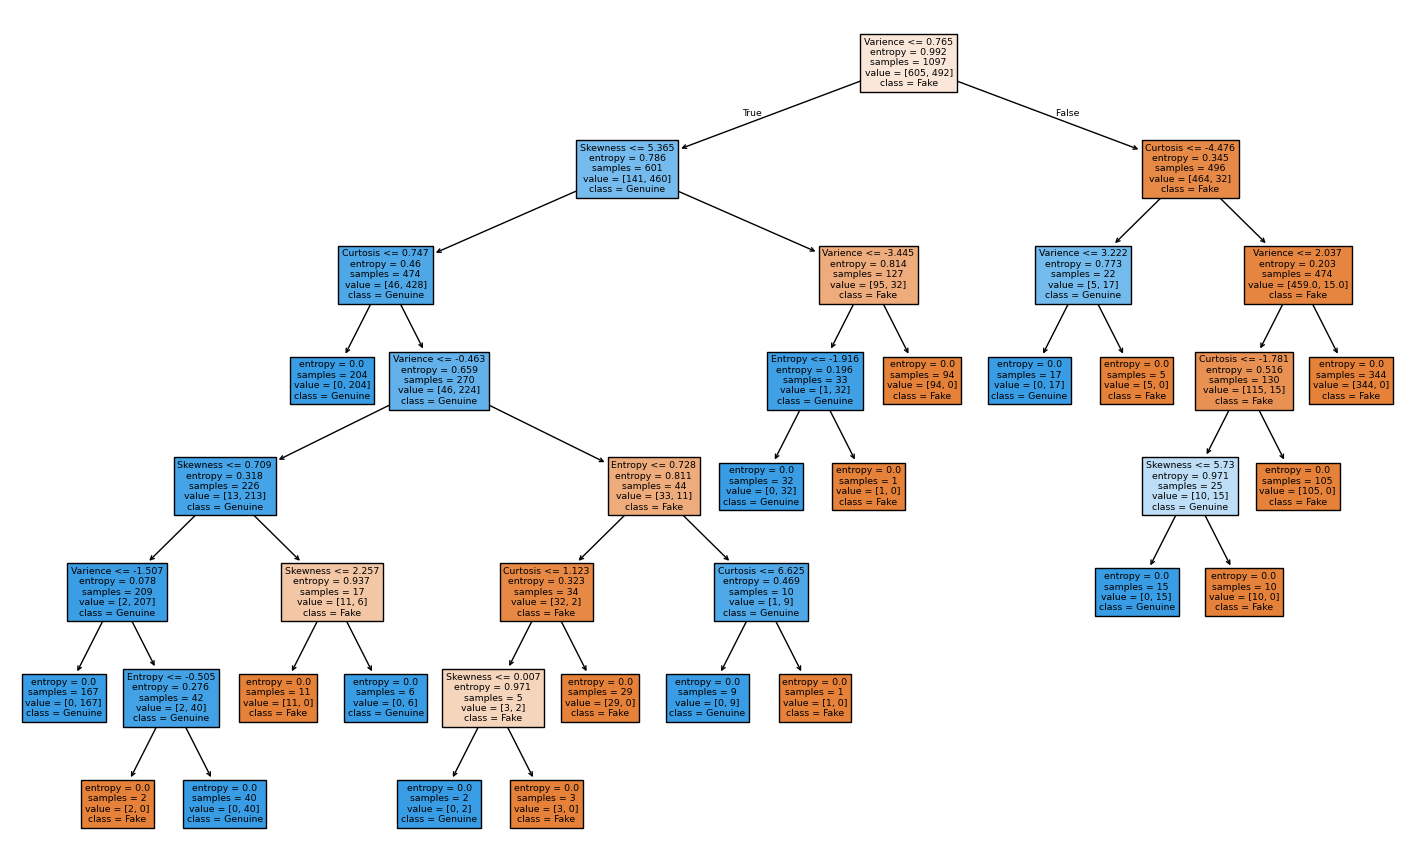

In [41]:
fig = plt.figure(figsize=(18,11))
_= tree.plot_tree(model2,
                  feature_names=['Varience','Skewness','Curtosis','Entropy'],
                  class_names=['Fake','Genuine'],
                  filled=True)
plt.savefig('feb_tree.png',dpi=80)